In [ ]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

pd.set_option('display.max_columns', 200)

In [ ]:
#importing day_csv data

day_csv = "data/day.csv"
day_df= pd.read_csv(day_csv)

DAY_CSV DATA UNDERSTANDING

In [ ]:
day_df.shape

In [ ]:
day_df.dtypes

In [ ]:
day_df.describe()

In [ ]:
day_df.columns

In [ ]:
day_df.head(20)

In [ ]:
day_df.isna().sum()

In [ ]:
#importing hour_csv data
hour_csv = "data/hour.csv"
hour_df = pd.read_csv(hour_csv)

HOUR_CSV DATA UNDERSTANDING

In [ ]:
hour_df.shape

In [ ]:
hour_df.dtypes

In [ ]:
hour_df.describe()

In [ ]:
hour_df.columns

In [ ]:
hour_df.head()

In [ ]:
hour_df.isna().sum()

DATA CLEANING

In [ ]:
#no duplicated values
print(f'Valores duplicados en day_csv: {day_df.duplicated().sum()}')
print(f'Valores duplicados en hour_csv: {hour_df.duplicated().sum()}')

In [ ]:
#transforming dteday into datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
display(day_df['dteday'].describe())
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])
display(hour_df['dteday'].describe())

In [70]:
#renaming columns and dropping somes
day_df = day_df.rename(columns={'dteday':'date',
                       'weathersit':'weather',
                       'yr':'year',
                       'mnth':'month',
                       'cnt':'rented_bikes'
                       })

In [74]:
hour_df = hour_df.rename(columns={'dteday':'date',
                       'weathersit':'weather',
                       'yr':'year',
                       'mnth':'month',
                       'cnt':'rented_bikes',
                       'hr':'hour'
                       })

In [ ]:
#exploratory data analysis
#there's missing hours on our dataset. We need a complete dataset if we want a model working properly

# 1. create a new column combining date and time. We use timedelta because to a timestamp we can only add duration
hour_df['datetime'] = pd.to_datetime(hour_df['date']) + pd.to_timedelta(hour_df['hour'], unit='h')

# 2. create the perfect range
complete_range = pd.date_range(
    start=hour_df['datetime'].min(), 
    end=hour_df['datetime'].max(), 
    freq='h' # 'h' means hourly frequency
)
    
# 3. we do difference to subtract the new column values to our perfect range (complete calendar)
#we do this because we need to know how many hours are we missing, so we can index them perfectly
missing_hours = complete_range.difference(hour_df['datetime']) 

# --- SHOW RESULTS ---
print(f"all missing hours detected: {len(missing_hours)}")
display(missing_hours[:10]) #we show the first 10 so we see everything is ok

# 4. indexing the new data. This will generate len(missing_hours) rows with NaN as a value for all of them
hour_df_reindex = hour_df.set_index('datetime')
completed_hour_df = hour_df_reindex.reindex(complete_range)

# 5. refilling data 
final_hour_df = completed_hour_df.copy()
#numerical_cols are the columns that only have numerical values (temperature, humidity...)
numerical_cols = completed_hour_df.select_dtypes(include=['number']).columns 
#interpolate only numerical columns
final_hour_df[numerical_cols] = completed_hour_df[numerical_cols].interpolate(method='time')
#fill not numerical columns so we dont break the model. This takes previous column text and put it on the empty next one
final_hour_df = final_hour_df.ffill()


all missing hours detected: 165


DatetimeIndex(['2011-01-02 05:00:00', '2011-01-03 02:00:00',
               '2011-01-03 03:00:00', '2011-01-04 03:00:00',
               '2011-01-05 03:00:00', '2011-01-06 03:00:00',
               '2011-01-07 03:00:00', '2011-01-11 03:00:00',
               '2011-01-11 04:00:00', '2011-01-12 03:00:00'],
              dtype='datetime64[us]', freq=None)

In [ ]:
#we create a general configuration for our graphics
sns.set_theme (
    style = 'darkgrid',
    palette = 'muted',
    context = 'talk',
    rc = {
        'figure.figsize' : (8,5),
        'axes.titlesize' : 16,
        'axes.labelsize' : 12
    },
)

In [75]:
hour_df.columns

Index(['instant', 'date', 'season', 'year', 'month', 'hour', 'holiday',
       'weekday', 'workingday', 'weather', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'rented_bikes', 'datetime'],
      dtype='str')

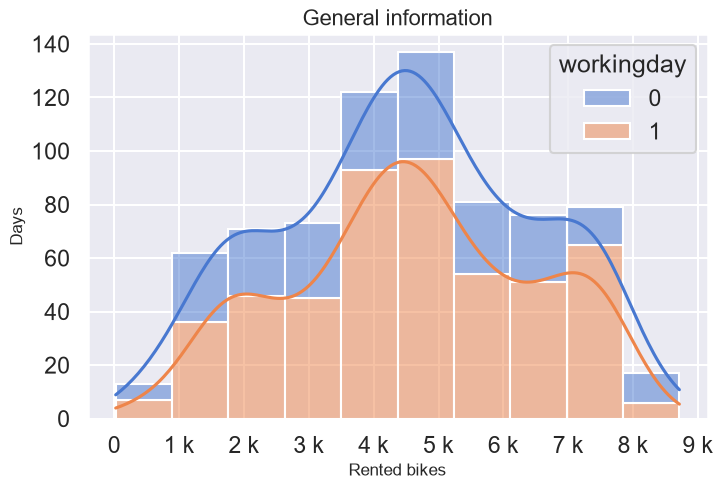

In [73]:
#first, histogram

sns.histplot(data=day_df, x='rented_bikes', bins=10, hue='workingday', multiple='stack', kde=True)
plt.xticks(range(0, 10000, 1000))

ax = plt.gca() # Recupera el gráfico actual
ax.xaxis.set_major_formatter(ticker.EngFormatter())

plt.title('General information')
plt.xlabel('Rented bikes')
plt.ylabel('Days')
plt.show()

In [ ]:
#searching for outliers. 


In [ ]:
#hour.csv . 0-23 fila forman una fila de la tabla de day (evidentemente, un día tiene 24 horas)
#weathersit: 1-despejado 2-niebla 3-lluvia débil 4-tormenta



In [ ]:
#Definición de la serie temporal. Gráficos que demuestren la temporalidad. Buscar tendencia y estacionalidad.


In [ ]:
#Transformaciones de la serie